Container 'A' contains 2 items:
  {'id': 1, 'category': 'A', 'value': 10}
  {'id': 3, 'category': 'A', 'value': 20}
Container 'B' contains 2 items:
  {'id': 2, 'category': 'B', 'value': 15}
  {'id': 5, 'category': 'B', 'value': 30}
Container 'C' contains 1 items:
  {'id': 4, 'category': 'C', 'value': 25}




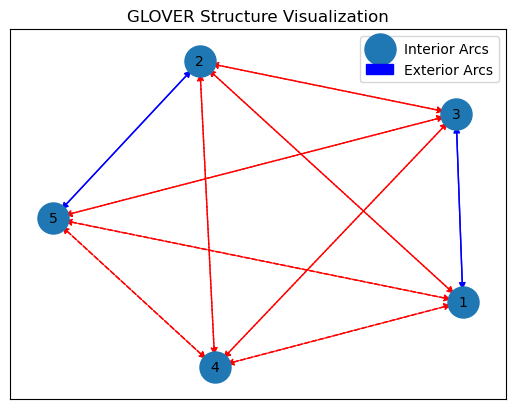

In [3]:
import json
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict

class GLOVER:
    def __init__(self, metric):
        self.metric = metric  # The field used to partition the dataset
        self.containers = defaultdict(list)  # Dictionary to hold the containers
        self.graph = nx.DiGraph()  # Directed graph for interior and exterior arcs

    def create_structure(self, dataset):
        """
        Convert a JSON dataset into a GLOVER structure with interior and exterior arcs.
        :param dataset: List of dictionaries (parsed JSON).
        """
        for item in dataset:
            if self.metric in item:
                metric_value = item[self.metric]
                self.containers[metric_value].append(item)
                # Add the node to the graph
                self.graph.add_node(item['id'], **item)
            else:
                raise ValueError(f"Metric '{self.metric}' not found in item: {item}")
        
        # Define arcs (both interior and exterior)
        self._add_arcs()

    def _add_arcs(self):
        """Add interior and exterior arcs to the graph."""
        for container, items in self.containers.items():
            # Add interior arcs (connections within the same container)
            for i, node_a in enumerate(items):
                for j, node_b in enumerate(items):
                    if i != j:  # Avoid self-loops
                        self.graph.add_edge(node_a['id'], node_b['id'], type='interior')

            # Add exterior arcs (connections between containers)
            for other_container, other_items in self.containers.items():
                if container != other_container:
                    for node_a in items:
                        for node_b in other_items:
                            self.graph.add_edge(node_a['id'], node_b['id'], type='exterior')

    def display_structure(self):
        """Print the GLOVER structure for inspection."""
        for container, items in self.containers.items():
            print(f"Container '{container}' contains {len(items)} items:")
            for item in items:
                print(f"  {item}")
        print("\n")

    def visualize(self):
        """Visualize the graph using networkx."""
        pos = nx.spring_layout(self.graph)
        interior_edges = [(u, v) for u, v, d in self.graph.edges(data=True) if d['type'] == 'interior']
        exterior_edges = [(u, v) for u, v, d in self.graph.edges(data=True) if d['type'] == 'exterior']

        # Draw nodes
        nx.draw_networkx_nodes(self.graph, pos, node_size=500)

        # Draw edges
        nx.draw_networkx_edges(self.graph, pos, edgelist=interior_edges, edge_color='blue', label='Interior Arcs')
        nx.draw_networkx_edges(self.graph, pos, edgelist=exterior_edges, edge_color='red', style='dashed', label='Exterior Arcs')

        # Draw labels
        nx.draw_networkx_labels(self.graph, pos, font_size=10, font_color='black')

        # Display
        plt.legend(['Interior Arcs', 'Exterior Arcs'])
        plt.title("GLOVER Structure Visualization")
        plt.show()

# Example Usage
if __name__ == "__main__":
    # Sample JSON dataset
    sample_json = """
    [
        {"id": 1, "category": "A", "value": 10},
        {"id": 2, "category": "B", "value": 15},
        {"id": 3, "category": "A", "value": 20},
        {"id": 4, "category": "C", "value": 25},
        {"id": 5, "category": "B", "value": 30}
    ]
    """
    dataset = json.loads(sample_json)

    # Create a GLOVER structure using 'category' as the metric
    glover = GLOVER(metric="category")
    glover.create_structure(dataset)

    # Display the structure
    glover.display_structure()

    # Visualize the structure
    glover.visualize()


In [5]:
import random

class GLOVER:
    def __init__(self, metric, random_prob=0.5):
        self.metric = metric
        self.containers = defaultdict(list)
        self.graph = nx.DiGraph()
        self.random_prob = random_prob  # Probability for generating random arcs

    def create_structure(self, dataset):
        for item in dataset:
            if self.metric in item:
                metric_value = item[self.metric]
                self.containers[metric_value].append(item)
                self.graph.add_node(item['id'], **item)
            else:
                raise ValueError(f"Metric '{self.metric}' not found in item: {item}")
        self._add_arcs()

    def _add_arcs(self):
        for container, items in self.containers.items():
            # Interior arcs with randomness
            for i, node_a in enumerate(items):
                for j, node_b in enumerate(items):
                    if i != j and random.random() < self.random_prob:
                        self.graph.add_edge(node_a['id'], node_b['id'], type='interior')

            # Exterior arcs with randomness
            for other_container, other_items in self.containers.items():
                if container != other_container:
                    for node_a in items:
                        for node_b in other_items:
                            if random.random() < self.random_prob:
                                self.graph.add_edge(node_a['id'], node_b['id'], type='exterior')

    def visualize(self):
        pos = nx.spring_layout(self.graph)
        interior_edges = [(u, v) for u, v, d in self.graph.edges(data=True) if d['type'] == 'interior']
        exterior_edges = [(u, v) for u, v, d in self.graph.edges(data=True) if d['type'] == 'exterior']

        nx.draw_networkx_nodes(self.graph, pos, node_size=500)
        nx.draw_networkx_edges(self.graph, pos, edgelist=interior_edges, edge_color='blue', label='Interior Arcs')
        nx.draw_networkx_edges(self.graph, pos, edgelist=exterior_edges, edge_color='red', style='dashed', label='Exterior Arcs')
        nx.draw_networkx_labels(self.graph, pos, font_size=10, font_color='black')

        plt.legend(['Interior Arcs', 'Exterior Arcs'])
        plt.title("Randomized GLOVER Structure")
        plt.show()


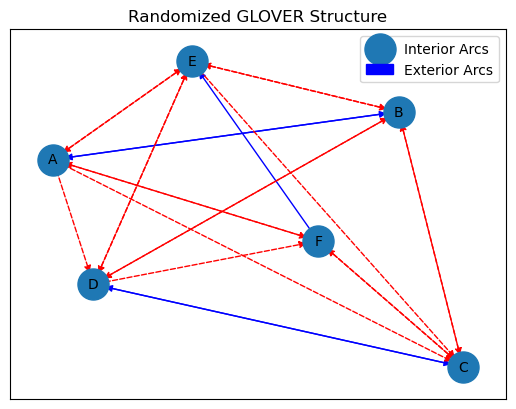

In [6]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict
import random

# Sample JSON-like dataset
dataset = [
    {"id": "A", "group": 1, "value": 10},
    {"id": "B", "group": 1, "value": 15},
    {"id": "C", "group": 2, "value": 20},
    {"id": "D", "group": 2, "value": 25},
    {"id": "E", "group": 3, "value": 30},
    {"id": "F", "group": 3, "value": 35}
]


# Create GLOVER structure
glover = GLOVER(metric="group", random_prob=0.7)
glover.create_structure(dataset)
glover.visualize()


In [9]:
import random
from collections import defaultdict
import networkx as nx
import matplotlib.pyplot as plt

class GLOVER:
    def __init__(self, interior_metric, exterior_metric, random_prob=0.5):
        self.interior_metric = interior_metric  # Metric for interior relationships
        self.exterior_metric = exterior_metric  # Metric for exterior relationships
        self.containers = defaultdict(list)
        self.graph = nx.DiGraph()
        self.random_prob = random_prob  # Probability for generating random arcs

    def create_structure(self, dataset):
        for item in dataset:
            if self.interior_metric in item:
                metric_value = item[self.interior_metric]
                self.containers[metric_value].append(item)
                self.graph.add_node(item['id'], **item)
            else:
                raise ValueError(f"Metric '{self.interior_metric}' not found in item: {item}")
        self._add_arcs()

    def _add_arcs(self):
        for container, items in self.containers.items():
            # Interior arcs with randomness
            for i, node_a in enumerate(items):
                for j, node_b in enumerate(items):
                    if i != j and random.random() < self.random_prob:
                        self.graph.add_edge(node_a['id'], node_b['id'], type='interior')

            # Exterior arcs with randomness
            for other_container, other_items in self.containers.items():
                if container != other_container:
                    for node_a in items:
                        for node_b in other_items:
                            # Use the exterior metric to determine relationships
                            if (node_a[self.exterior_metric] == node_b[self.exterior_metric] 
                                and random.random() < self.random_prob):
                                self.graph.add_edge(node_a['id'], node_b['id'], type='exterior')

    def visualize(self):
        pos = nx.spring_layout(self.graph)
        interior_edges = [(u, v) for u, v, d in self.graph.edges(data=True) if d['type'] == 'interior']
        exterior_edges = [(u, v) for u, v, d in self.graph.edges(data=True) if d['type'] == 'exterior']

        nx.draw_networkx_nodes(self.graph, pos, node_size=500)
        nx.draw_networkx_edges(self.graph, pos, edgelist=interior_edges, edge_color='blue', label='Interior Arcs')
        nx.draw_networkx_edges(self.graph, pos, edgelist=exterior_edges, edge_color='red', style='dashed', label='Exterior Arcs')
        nx.draw_networkx_labels(self.graph, pos, font_size=10, font_color='black')

        plt.legend(['Interior Arcs', 'Exterior Arcs'])
        plt.title("Randomized GLOVER Structure")
        plt.show()

    def print_containers(self):
        """Prints the contents of each container for inspection."""
        for container, nodes in self.containers.items():
            print(f"Container {container}:")
            for node in nodes:
                print(f"  Node ID: {node['id']}, Data: {node}")


Container A:
  Node ID: 1, Data: {'id': 1, 'interior_metric': 'A', 'exterior_metric': 10}
  Node ID: 2, Data: {'id': 2, 'interior_metric': 'A', 'exterior_metric': 20}
Container B:
  Node ID: 3, Data: {'id': 3, 'interior_metric': 'B', 'exterior_metric': 10}
  Node ID: 4, Data: {'id': 4, 'interior_metric': 'B', 'exterior_metric': 30}


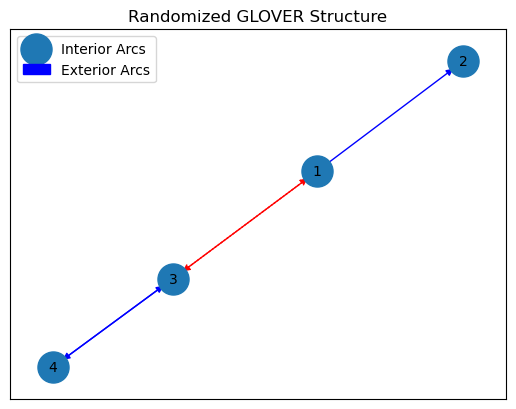

In [10]:
dataset = [
    {'id': 1, 'interior_metric': 'A', 'exterior_metric': 10},
    {'id': 2, 'interior_metric': 'A', 'exterior_metric': 20},
    {'id': 3, 'interior_metric': 'B', 'exterior_metric': 10},
    {'id': 4, 'interior_metric': 'B', 'exterior_metric': 30},
]

glover = GLOVER(interior_metric='interior_metric', exterior_metric='exterior_metric', random_prob=0.7)
glover.create_structure(dataset)

# View the containers
glover.print_containers()

# Visualize the graph
glover.visualize()


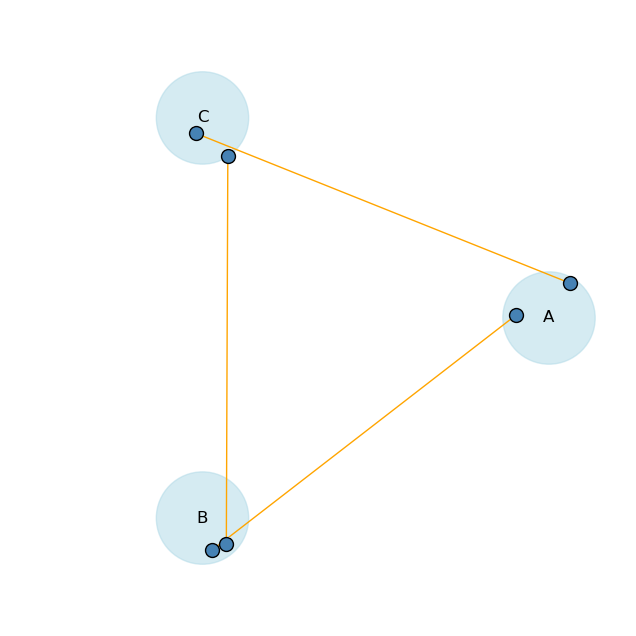

In [11]:
import matplotlib.pyplot as plt
import networkx as nx
import random
import numpy as np

# Create a random dataset (equivalent to your JSON input)
dataset = [
    {"id": 1, "metric1": "A", "metric2": "X"},
    {"id": 2, "metric1": "A", "metric2": "Y"},
    {"id": 3, "metric1": "B", "metric2": "X"},
    {"id": 4, "metric1": "B", "metric2": "Z"},
    {"id": 5, "metric1": "C", "metric2": "Y"},
    {"id": 6, "metric1": "C", "metric2": "Z"}
]

# Extract unique containers (based on 'metric1')
containers = list(set(d["metric1"] for d in dataset))

# Initialize a graph
G = nx.Graph()

# Add nodes to the graph
for d in dataset:
    G.add_node(d["id"], metric1=d["metric1"], metric2=d["metric2"])

# Create a circular layout for containers and nodes
container_positions = {}
node_positions = {}

# Define the radius and the center for the layout
radius = 3
center = (0, 0)

# Position the containers in a circular layout
angle_step = 2 * np.pi / len(containers)
for i, container in enumerate(containers):
    angle = angle_step * i
    x = center[0] + radius * np.cos(angle)
    y = center[1] + radius * np.sin(angle)
    container_positions[container] = (x, y)

# Position the nodes inside their corresponding containers
for node_id, data in enumerate(dataset, start=1):
    container = data["metric1"]
    container_x, container_y = container_positions[container]
    
    # Randomize the position within the container
    offset_x = random.uniform(-0.5, 0.5)
    offset_y = random.uniform(-0.5, 0.5)
    
    node_positions[node_id] = (container_x + offset_x, container_y + offset_y)

# Create edges between nodes with the same metric2 (optional)
for i, d1 in enumerate(dataset):
    for j, d2 in enumerate(dataset):
        if i != j and d1["metric2"] == d2["metric2"]:
            G.add_edge(d1["id"], d2["id"])

# Draw the containers (as circles)
fig, ax = plt.subplots(figsize=(8, 8))
for container, (x, y) in container_positions.items():
    ax.add_patch(plt.Circle((x, y), 0.6, color='lightblue', alpha=0.5))
    ax.text(x, y, container, ha="center", va="center", fontsize=12, color='black')

# Draw the nodes
for node_id, (x, y) in node_positions.items():
    ax.scatter(x, y, s=100, c='steelblue', edgecolors='black', zorder=5)
    ax.text(x, y, str(node_id), ha="center", va="center", fontsize=12, color='white')

# Draw edges (arcs) between nodes
for edge in G.edges():
    node1_pos = node_positions[edge[0]]
    node2_pos = node_positions[edge[1]]
    ax.plot([node1_pos[0], node2_pos[0]], [node1_pos[1], node2_pos[1]], color="orange", lw=1)

# Customize the plot
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.set_aspect('equal')
ax.axis('off')
plt.show()


In [12]:
initialize_graph(cities, edges)
initialize_containers()

def bfs_priority(graph, start_node, time_limit, mutation_prob):
    priority_queue = PriorityQueue()
    priority_queue.put((0, start_node))  # (distance, node)
    visited = set()

    while not priority_queue.empty():
        current_dist, current_node = priority_queue.get()
        if current_node in visited:
            continue
        visited.add(current_node)

        for neighbor, weight in graph[current_node]:
            if neighbor not in visited and within_time_limit(neighbor, time_limit):
                priority = calculate_priority(neighbor, mutation_prob, weight)
                priority_queue.put((priority, neighbor))

        update_containers(current_node)

    return generate_flight_plan(visited)

def calculate_priority(node, mutation_prob, weight):
    safety_score = 1 - mutation_prob[node]
    return weight / safety_score  # Prefer safer and closer cities

flight_plan = bfs_priority(graph, start_city, time_limit, mutation_probs)
optimize_flight_plan(flight_plan)


NameError: name 'initialize_graph' is not defined

In [13]:
import random

class GLOVER:
    def __init__(self, metric, random_prob=0.5):
        self.metric = metric
        self.containers = defaultdict(list)
        self.graph = nx.DiGraph()
        self.random_prob = random_prob  # Probability for generating random arcs

    def create_structure(self, dataset):
        for item in dataset:
            if self.metric in item:
                metric_value = item[self.metric]
                self.containers[metric_value].append(item)
                self.graph.add_node(item['id'], **item)
            else:
                raise ValueError(f"Metric '{self.metric}' not found in item: {item}")
        self._add_arcs()

    def _add_arcs(self):
        for container, items in self.containers.items():
            # Interior arcs with randomness
            for i, node_a in enumerate(items):
                for j, node_b in enumerate(items):
                    if i != j and random.random() < self.random_prob:
                        self.graph.add_edge(node_a['id'], node_b['id'], type='interior')

            # Exterior arcs with randomness
            for other_container, other_items in self.containers.items():
                if container != other_container:
                    for node_a in items:
                        for node_b in other_items:
                            if random.random() < self.random_prob:
                                self.graph.add_edge(node_a['id'], node_b['id'], type='exterior')

    def visualize(self):
        pos = nx.spring_layout(self.graph)
        interior_edges = [(u, v) for u, v, d in self.graph.edges(data=True) if d['type'] == 'interior']
        exterior_edges = [(u, v) for u, v, d in self.graph.edges(data=True) if d['type'] == 'exterior']

        nx.draw_networkx_nodes(self.graph, pos, node_size=500)
        nx.draw_networkx_edges(self.graph, pos, edgelist=interior_edges, edge_color='blue', label='Interior Arcs')
        nx.draw_networkx_edges(self.graph, pos, edgelist=exterior_edges, edge_color='red', style='dashed', label='Exterior Arcs')
        nx.draw_networkx_labels(self.graph, pos, font_size=10, font_color='black')

        plt.legend(['Interior Arcs', 'Exterior Arcs'])
        plt.title("Randomized GLOVER Structure")
        plt.show()
